# AI ????????????

?? MA5/MA20 ????????????????????????????????????????? 1 ????????????????????? `_latest()`?

[2026-07-21 13:19:46] [info     ] 因子计算开始                         end='2024-10-31 23:59:59' start='2024-01-01 00:00:00'
[2026-07-21 13:19:53] [info     ] 日频量价查询完成                       rows=170825 table=bigalpha_2026_stock_bar1m
[2026-07-21 13:19:58] [info     ] 开始训练 XGBoost                   samples=123572
[2026-07-21 13:21:13] [info     ] 日频量价查询完成                       rows=476630 table=bigalpha_2026_stock_bar1m_selftest
[2026-07-21 13:21:19] [info     ] 因子构建完成                         elapsed=93.01 rows=198821
[2026-07-21 13:21:19] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-07-21 13:21:22] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-07-21 13:21:22] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-07-21 13:21:22] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-10-31
[2026-07-21 13:21:22] [info     ] ========== 数据检查 ==========
[2026-07-21 13:21:22] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['f

时段,IC
2024-01-15~2024-02-08,0.0410
2024-09-24~2024-10-08,-0.0384

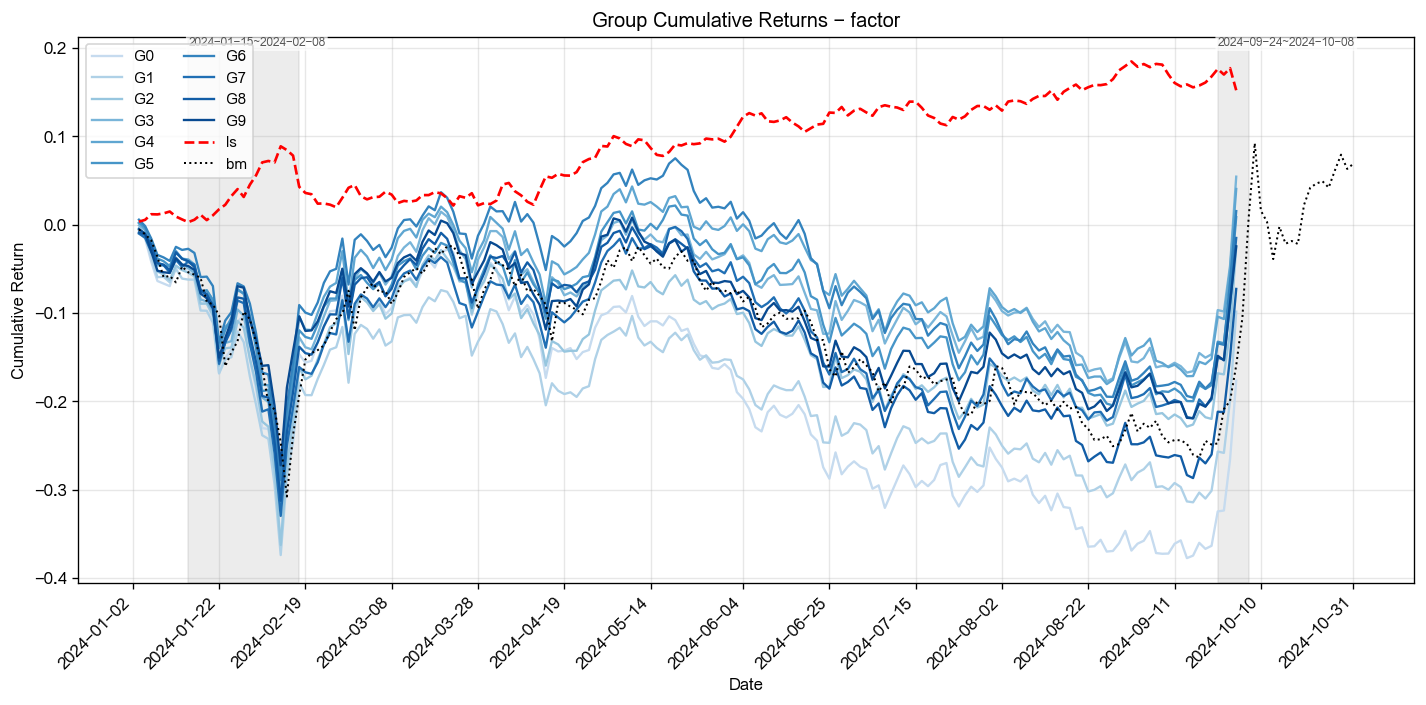
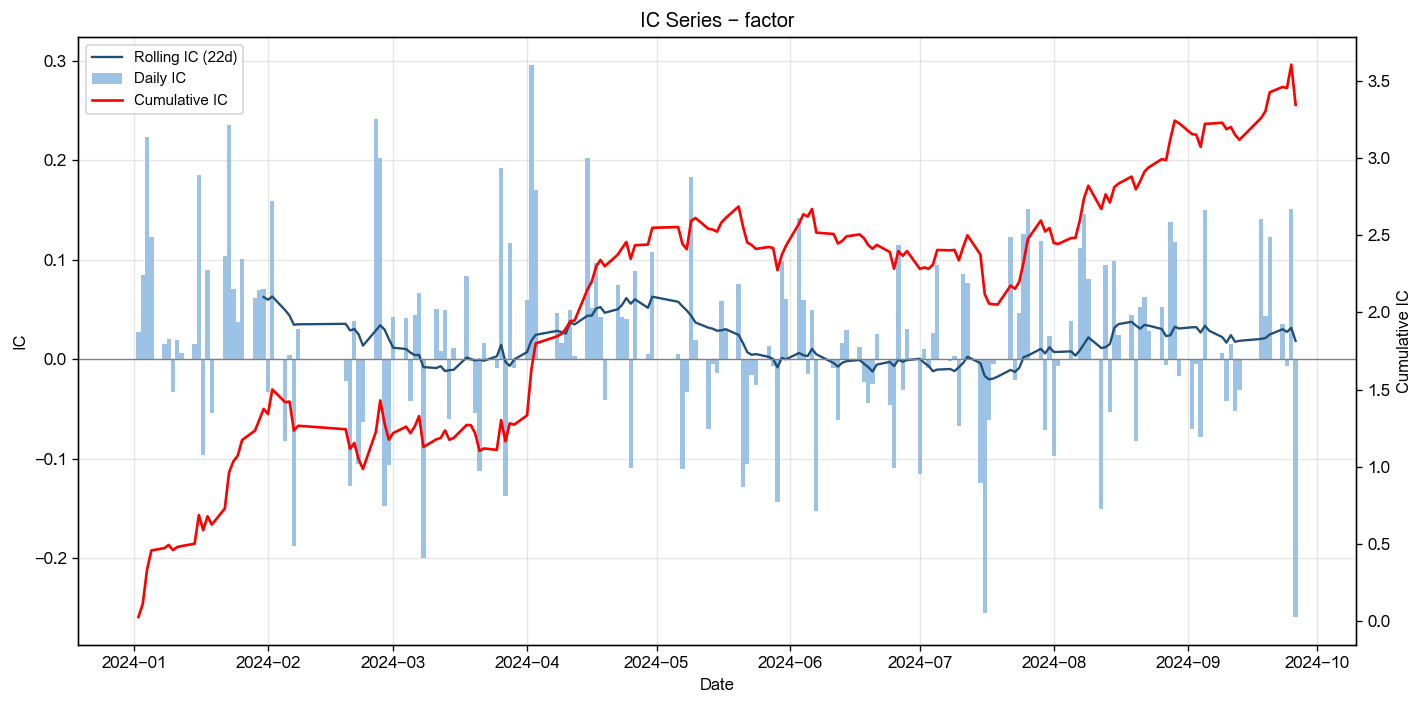
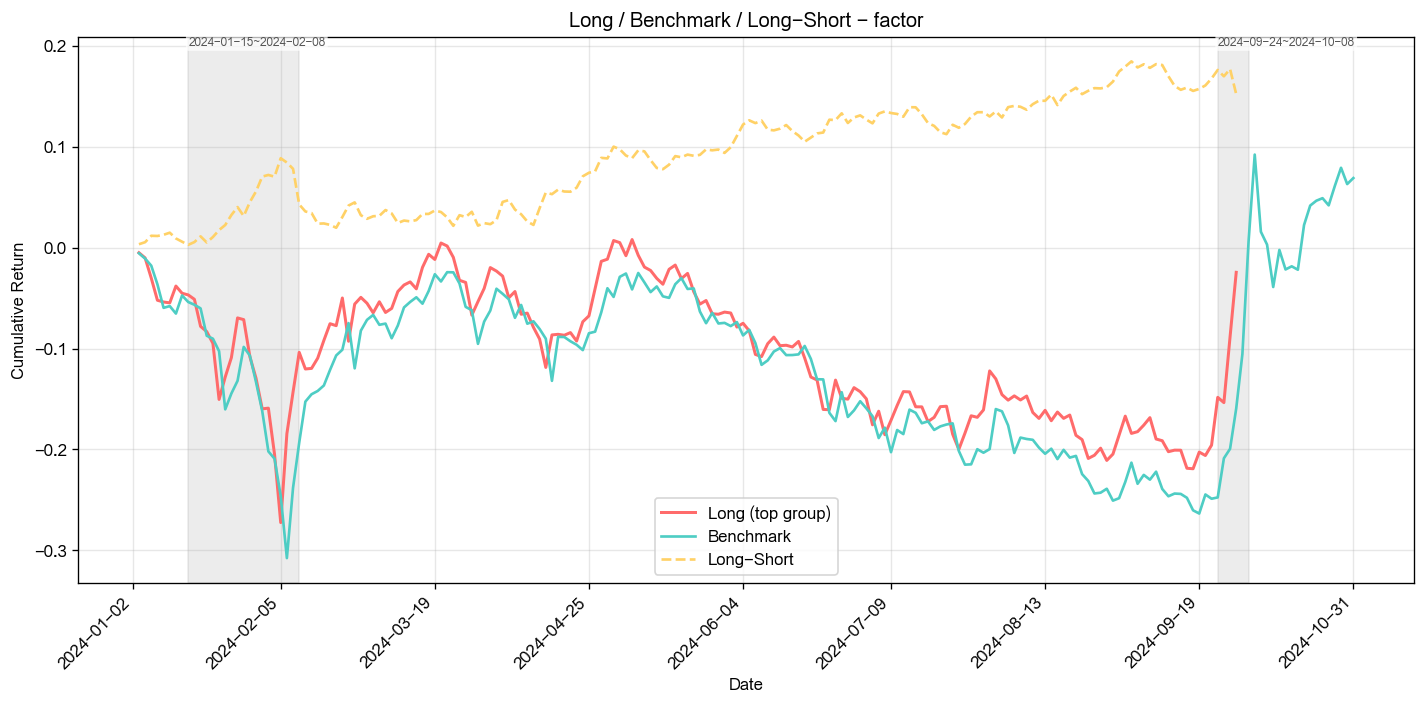
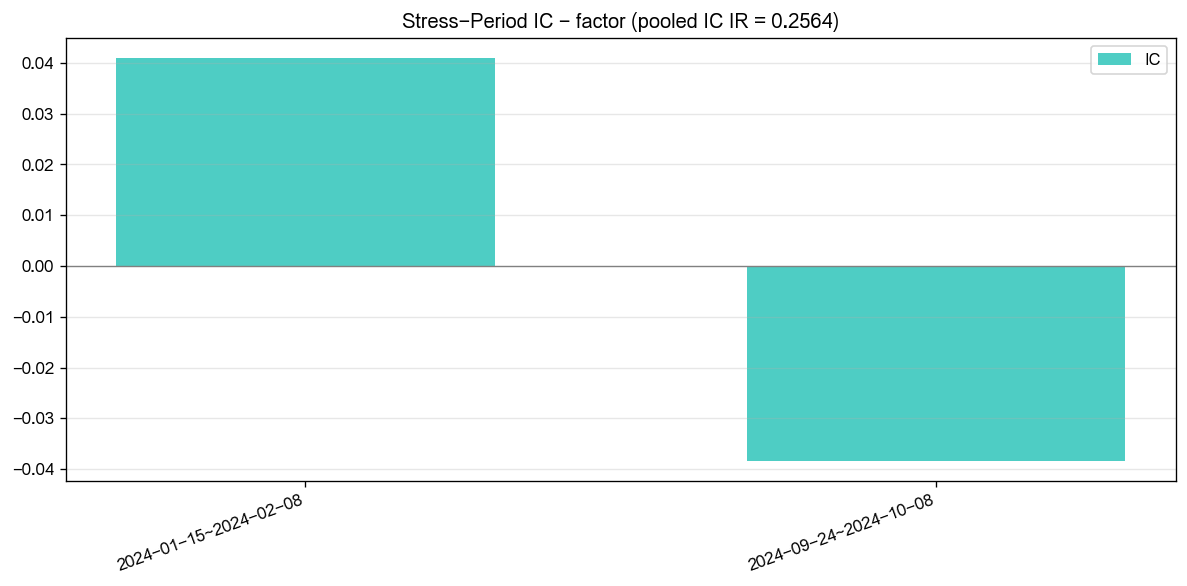
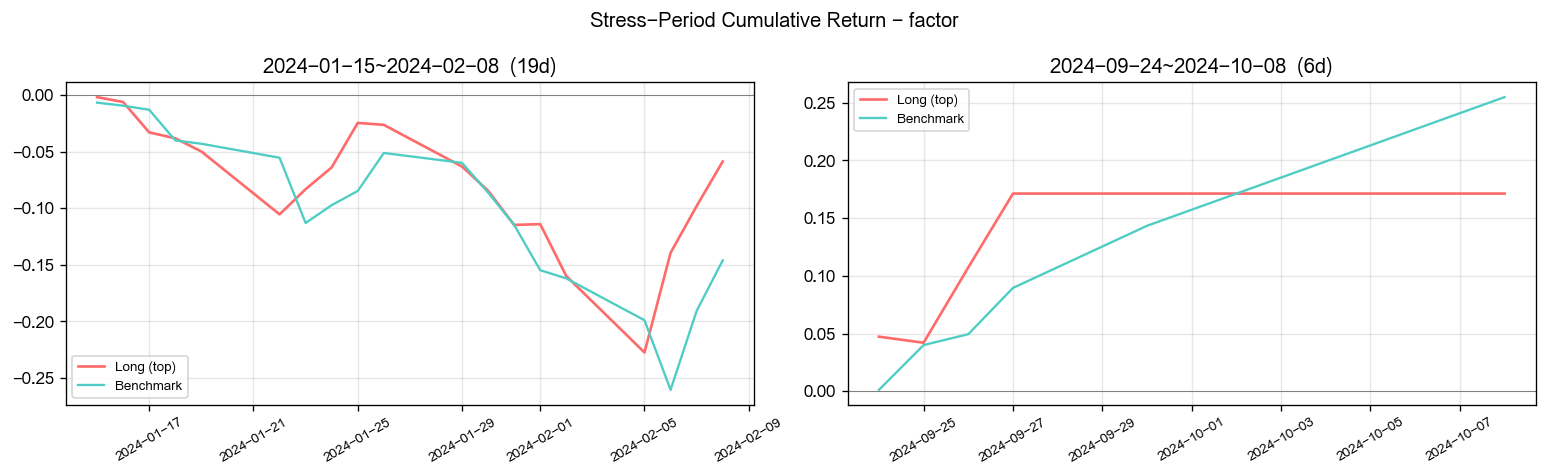

[2026-07-21 13:22:30] [info     ] ========== 因子池回归 ==========
[2026-07-21 13:22:30] [info     ] 加载 T+1 收益数据完成                  end_date=2024-10-31 instrument_count=1106 rows=228070 start_date=2024-01-02
[2026-07-21 13:22:31] [info     ] 获取收益率数据, 耗时: 0.726 秒
[2026-07-21 13:22:32] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.3709 秒
[2026-07-21 13:22:32] [info     ] 统计 回归结果, 耗时: 0.01 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,kdj_d_9_3_3,2.6396,0.0157,0.0059,1.0000
2,netflow_amount_rate_main,2.2654,0.0063,0.0028,1.0000
3,gross_profit_rate_ttm,1.8318,0.0079,0.0043,1.0000
4,amount,1.8256,0.0205,0.0112,1.0000
5,volatility_5,1.8048,0.0230,0.0128,1.0000
6,factor,1.7724,0.0082,0.0046,1.0000
7,roa_avg_ttm,1.6628,0.0157,0.0094,0.8571
8,rsi_12,1.6120,0.0397,0.0246,1.0000
9,pb,1.5445,0.0064,0.0041,1.0000
10,net_profit_rate_ttm,1.5351,0.0045,0.0029,0.8571

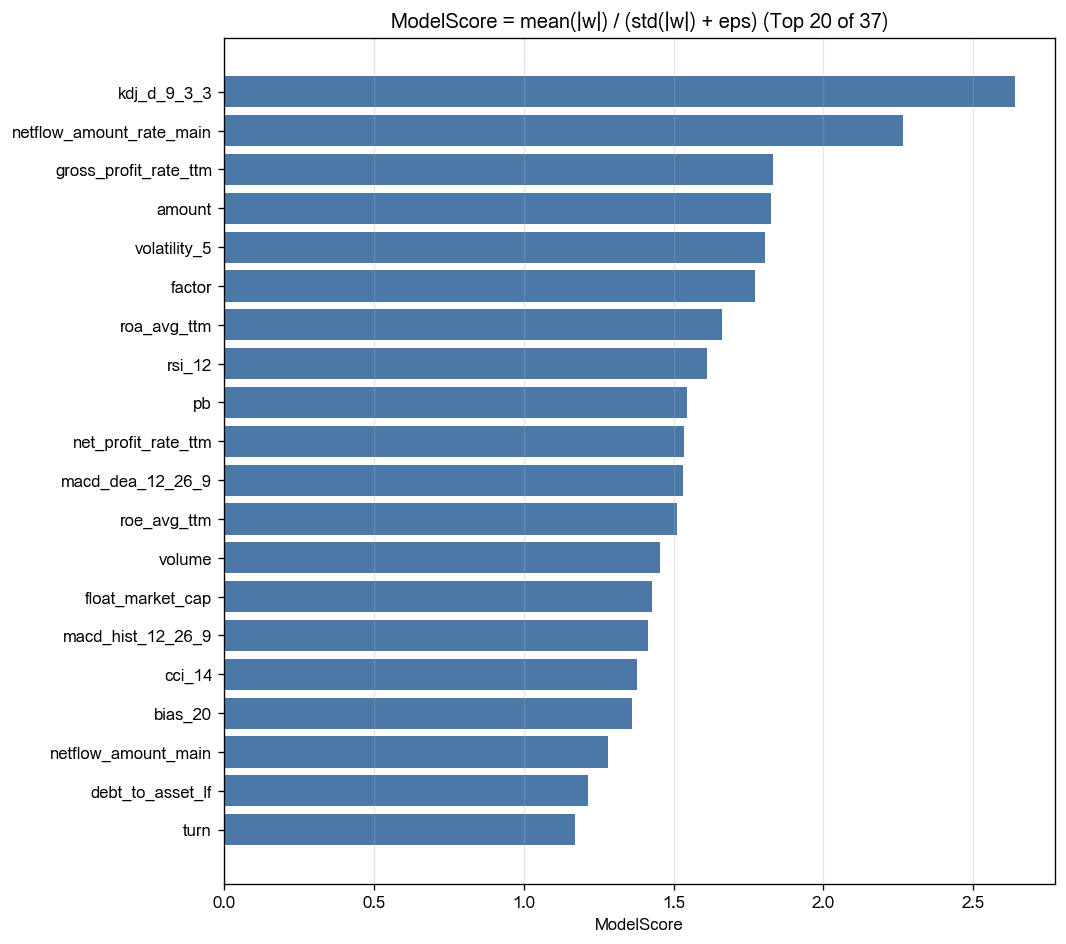
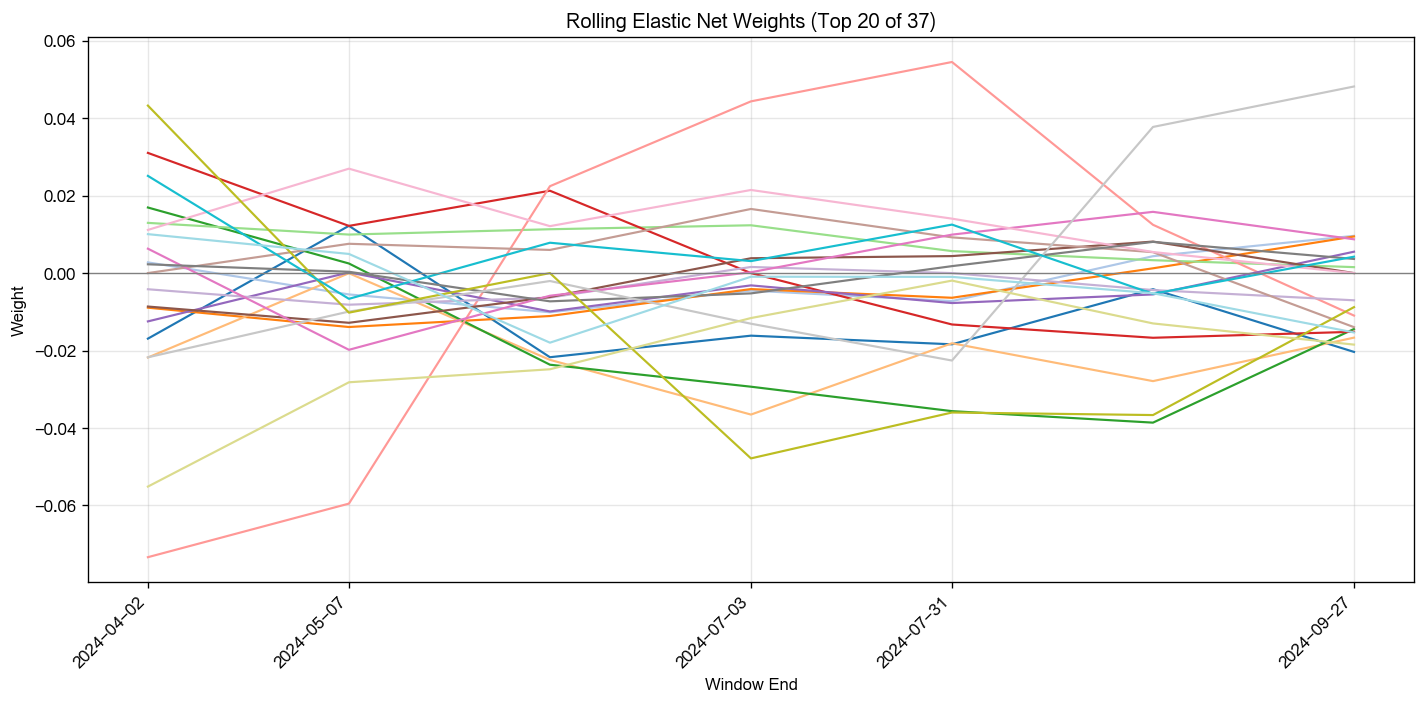
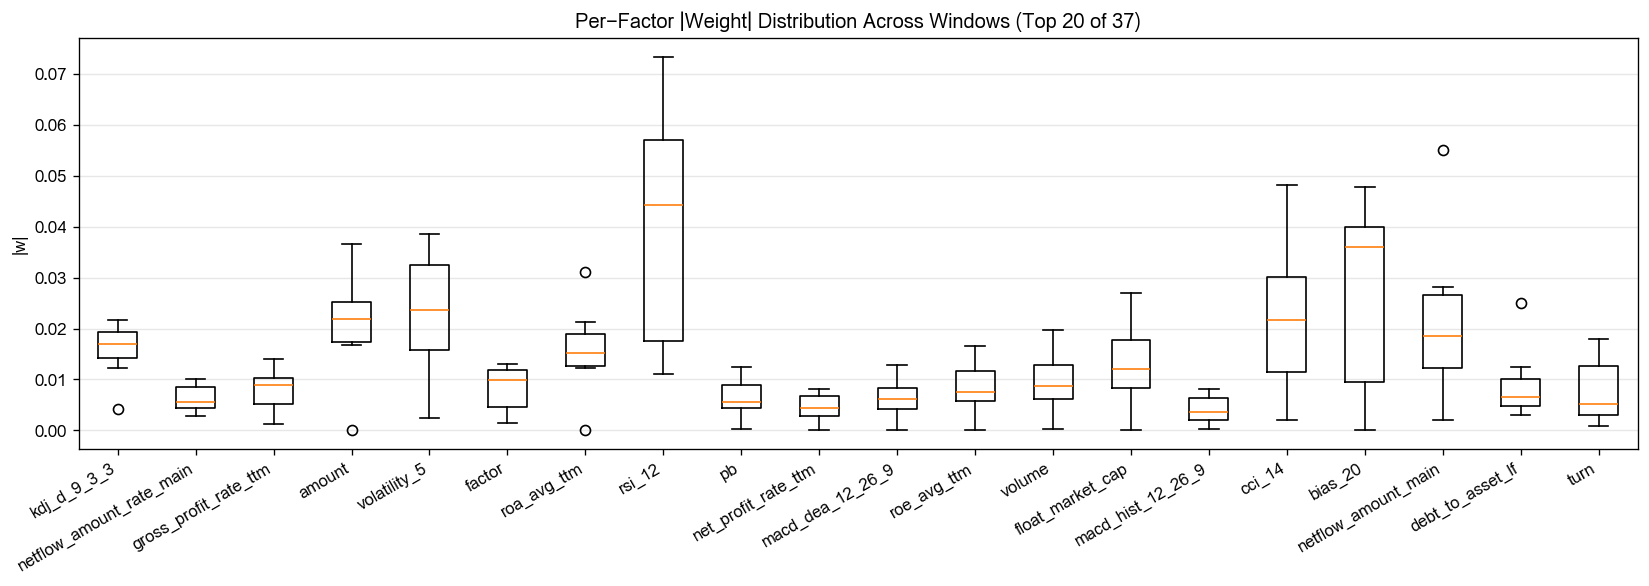
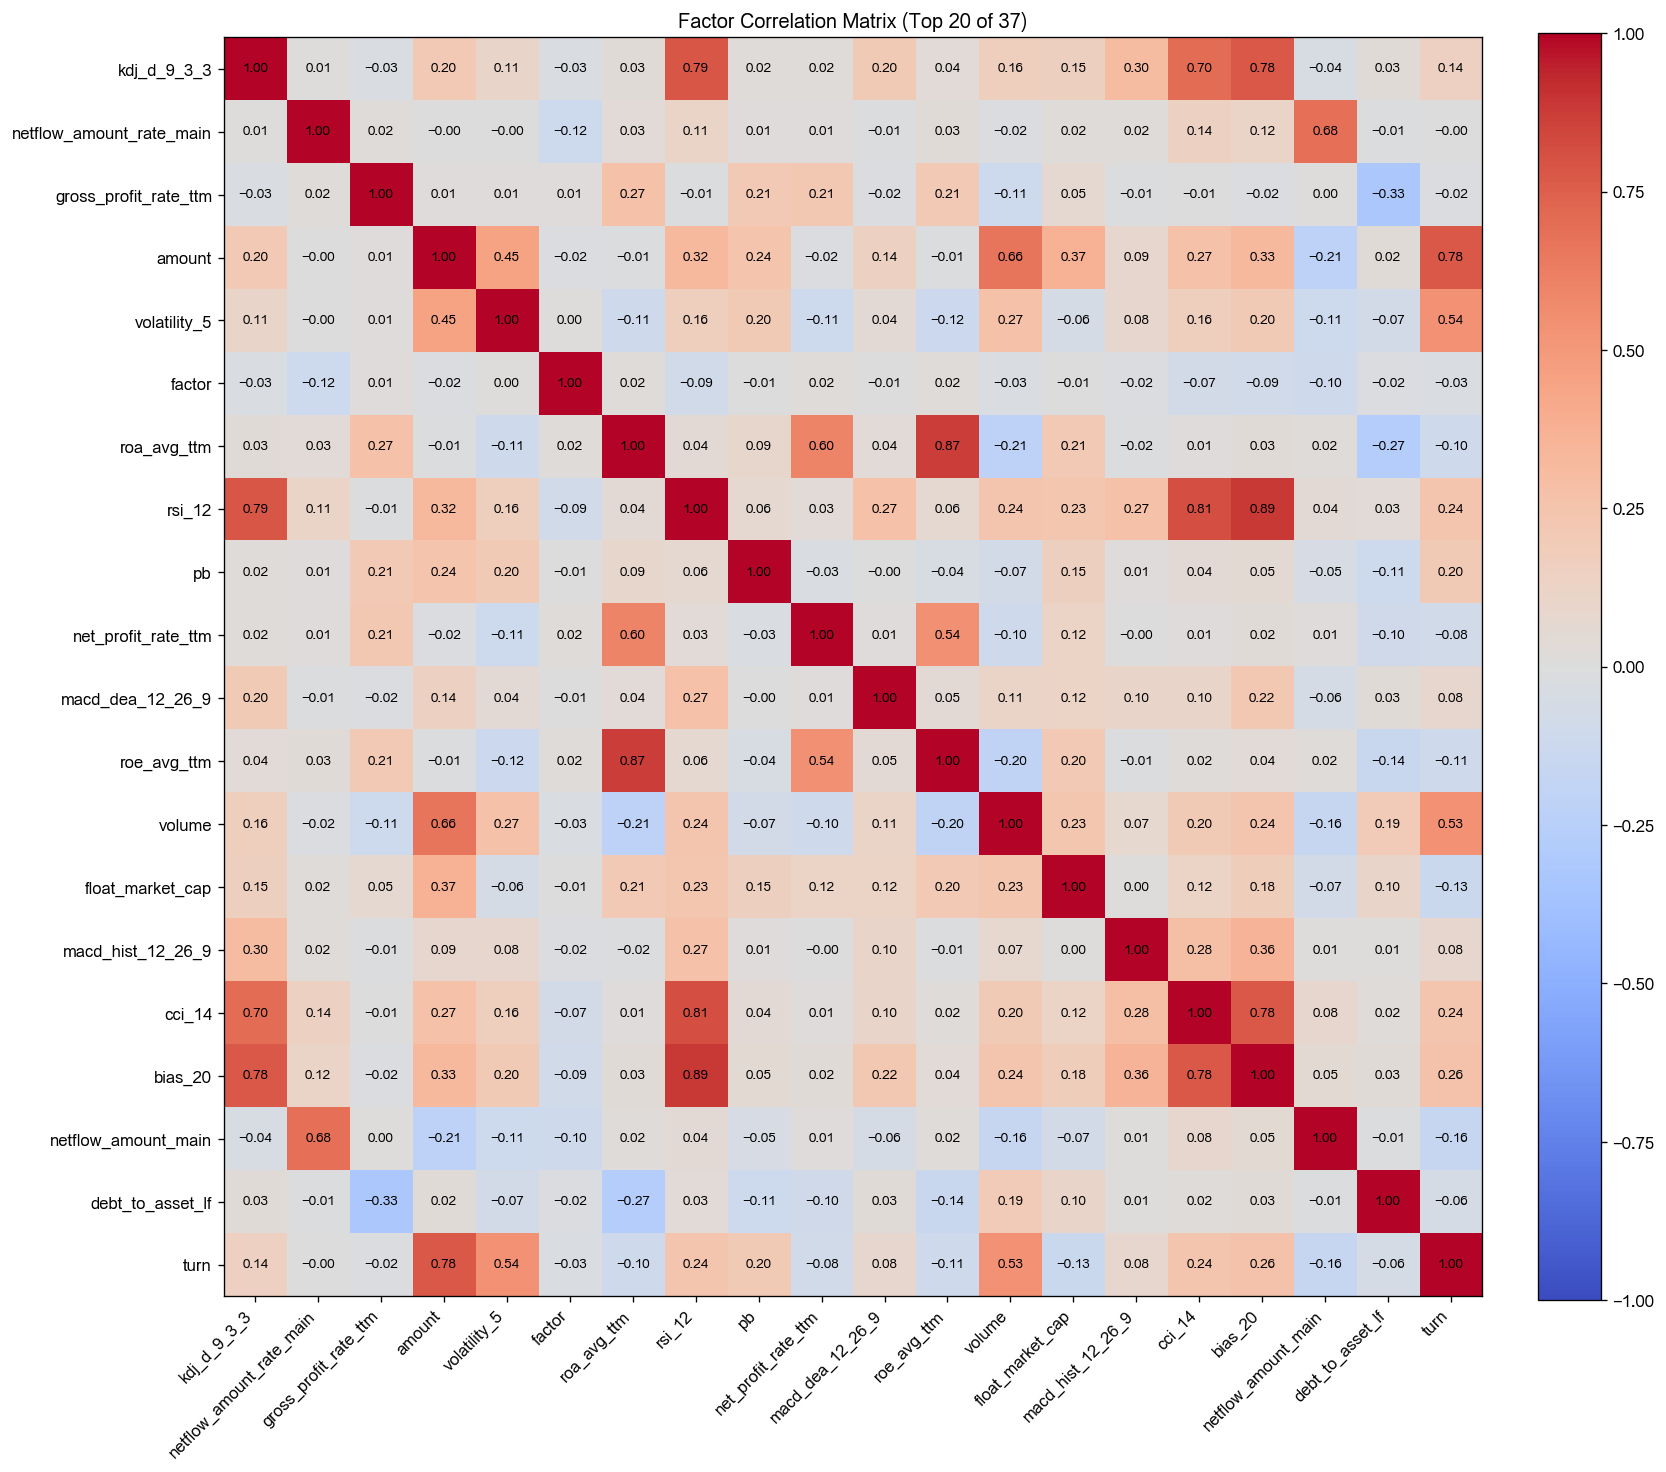

[2026-07-21 13:22:35] [warning  ] 返回的Outputs实例(size=28451855) 大于 64K, 将不会被缓存
[2026-07-21 13:22:35] [info     ] bigalpha_eval.v4 运行完成 [72.864s].


In [1]:
import numpy as np
import pandas as pd


TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END = "2023-03-31 23:59:59"
TRAIN_BAR_TABLE = "bigalpha_2026_stock_bar1m"
SEED = 20260720

FEATURES = [
    "daily_return",
    "path_range",
    "path_recovery",
    "path_efficiency",
    "log_amount",
    "log_volume",
    "range_contraction",
    "amount_fatigue",
    "recovery_memory",
    "ret_1",
    "ret_5",
    "ret_20",
    "ma_gap_5_20",
    "early_return",
    "late_return",
    "intraday_reversal",
    "late_amount_share",
    "late_volume_share",
    "vol_5",
    "volume_change_5",
    "avg_bar_amount",
]


def _log(logger, message, **kwargs):
    if logger is not None:
        logger.info(message, **kwargs)


def _daily_features(table, start_date, end_date, dai, logger=None):
    start = pd.Timestamp(start_date)
    end = pd.Timestamp(end_date)
    query_start = start - pd.Timedelta(days=30)
    sql = f"""
    SELECT
        date_trunc('day', date)::DATE AS date,
        instrument,
        arg_min(open, date) AS open,
        max(high) AS high,
        min(low) AS low,
        arg_max(close, date) AS close,
        sum(volume) AS volume,
        sum(amount) AS amount,
        count(*) AS bar_count,
        arg_min(open, date) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 570
              AND date_part('hour', date) * 60 + date_part('minute', date) < 600
        ) AS early_open,
        arg_max(close, date) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 570
              AND date_part('hour', date) * 60 + date_part('minute', date) < 600
        ) AS early_close,
        arg_min(open, date) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 870
              AND date_part('hour', date) * 60 + date_part('minute', date) < 900
        ) AS late_open,
        arg_max(close, date) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 870
              AND date_part('hour', date) * 60 + date_part('minute', date) < 900
        ) AS late_close,
        sum(amount) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 870
              AND date_part('hour', date) * 60 + date_part('minute', date) < 900
        ) AS late_amount,
        sum(volume) FILTER (
            WHERE date_part('hour', date) * 60 + date_part('minute', date) >= 870
              AND date_part('hour', date) * 60 + date_part('minute', date) < 900
        ) AS late_volume
    FROM {table}
    GROUP BY 1, 2
    ORDER BY 1, 2
    """
    raw = dai.query(
        sql,
        filters={
            "date": [
                query_start.strftime("%Y-%m-%d %H:%M:%S"),
                end.strftime("%Y-%m-%d %H:%M:%S"),
            ]
        },
    ).df()
    if raw.empty:
        raise ValueError(f"No daily rows returned from {table}.")
    _log(logger, "日频量价查询完成", rows=len(raw), table=str(table))

    raw["date"] = pd.to_datetime(raw["date"], errors="coerce").dt.normalize()
    raw["instrument"] = raw["instrument"].astype(str)
    for column in [
        "open", "high", "low", "close", "volume", "amount", "bar_count",
        "early_open", "early_close", "late_open", "late_close",
        "late_amount", "late_volume",
    ]:
        raw[column] = pd.to_numeric(raw[column], errors="coerce")
    raw = raw.sort_values(["instrument", "date"]).reset_index(drop=True)
    raw["amount"] = raw["amount"].fillna(0.0).clip(lower=0.0)
    raw["volume"] = raw["volume"].fillna(0.0).clip(lower=0.0)
    raw["bar_count"] = raw["bar_count"].fillna(1.0).clip(lower=1.0)

    open_denom = raw["open"].replace(0, np.nan)
    range_abs = (raw["high"] - raw["low"]).replace(0, np.nan)
    raw["daily_return"] = raw["close"] / open_denom - 1.0
    raw["path_range"] = (raw["high"] - raw["low"]) / open_denom
    raw["path_recovery"] = (raw["close"] - raw["low"]) / range_abs
    raw["path_efficiency"] = raw["daily_return"].abs() / raw["path_range"].replace(0, np.nan)
    raw["early_return"] = raw["early_close"] / raw["early_open"] - 1.0
    raw["late_return"] = raw["late_close"] / raw["late_open"] - 1.0
    raw["intraday_reversal"] = raw["late_return"] - raw["early_return"]
    raw["late_amount_share"] = raw["late_amount"] / raw["amount"].replace(0, np.nan)
    raw["late_volume_share"] = raw["late_volume"] / raw["volume"].replace(0, np.nan)
    raw["log_amount"] = np.log1p(raw["amount"])
    raw["log_volume"] = np.log1p(raw["volume"])
    raw["avg_bar_amount"] = raw["amount"] / raw["bar_count"]

    grouped = raw.groupby("instrument", sort=False)
    raw["range_memory"] = grouped["path_range"].transform(
        lambda x: x.rolling(20, min_periods=3).mean()
    )
    raw["amount_memory"] = grouped["log_amount"].transform(
        lambda x: x.rolling(20, min_periods=3).mean()
    )
    raw["range_contraction"] = raw["range_memory"] - raw["path_range"]
    raw["amount_fatigue"] = raw["log_amount"] - raw["amount_memory"]
    raw["recovery_memory"] = grouped["path_recovery"].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    raw["ret_1"] = grouped["close"].pct_change(1)
    raw["ret_5"] = grouped["close"].pct_change(5)
    raw["ret_20"] = grouped["close"].pct_change(20)
    ma_5 = grouped["close"].transform(
        lambda x: x.rolling(5, min_periods=3).mean()
    )
    ma_20 = grouped["close"].transform(
        lambda x: x.rolling(20, min_periods=10).mean()
    )
    raw["ma_gap_5_20"] = ma_5 / ma_20.replace(0, np.nan) - 1.0
    one_day = grouped["close"].pct_change(1)
    raw["vol_5"] = one_day.groupby(raw["instrument"], sort=False).transform(
        lambda x: x.rolling(5, min_periods=4).std()
    )
    raw["volume_change_5"] = grouped["volume"].pct_change(5)
    raw["label"] = grouped["close"].shift(-1) / raw["close"] - 1.0
    raw = raw.replace([np.inf, -np.inf], np.nan)
    return raw[
        (raw["date"] >= start.normalize()) & (raw["date"] <= end.normalize())
    ].reset_index(drop=True)


def _fit_model(train, logger=None):
    try:
        import xgboost as xgb

        model = xgb.XGBRegressor(
            n_estimators=12,
            max_depth=3,
            learning_rate=0.08,
            subsample=0.8,
            colsample_bytree=0.85,
            min_child_weight=10,
            reg_lambda=2.0,
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=SEED,
        )
    except Exception:
        try:
            from sklearn.ensemble import HistGradientBoostingRegressor

            model = HistGradientBoostingRegressor(
                max_iter=80,
                max_leaf_nodes=16,
                learning_rate=0.08,
                min_samples_leaf=10,
                l2_regularization=2.0,
                random_state=SEED,
            )
        except Exception:
            model = _NumpyRidge(alpha=10.0)
    _log(logger, "开始训练 XGBoost", samples=len(train))
    model.fit(train[FEATURES].astype("float32"), train["label"].astype("float32"))
    return model


class _NumpyRidge:
    """Dependency-free fallback for local environments without sklearn."""

    def __init__(self, alpha=10.0):
        self.alpha = float(alpha)

    def fit(self, x, y):
        values = np.nan_to_num(np.asarray(x, dtype=np.float64), nan=0.0)
        target = np.asarray(y, dtype=np.float64)
        self.mean_ = values.mean(axis=0)
        self.scale_ = values.std(axis=0)
        self.scale_[self.scale_ < 1e-8] = 1.0
        z = (values - self.mean_) / self.scale_
        design = np.column_stack([np.ones(len(z)), z])
        penalty = np.eye(design.shape[1]) * self.alpha
        penalty[0, 0] = 0.0
        self.coef_ = np.linalg.pinv(design.T @ design + penalty) @ design.T @ target
        return self

    def predict(self, x):
        values = np.nan_to_num(np.asarray(x, dtype=np.float64), nan=0.0)
        z = (values - self.mean_) / self.scale_
        return np.column_stack([np.ones(len(z)), z]) @ self.coef_


def main(datasources, start_date, end_date):
    """
    因子构建主函数。

    训练区间固定，平台传入的 start_date/end_date 只用于样本外预测。
    返回严格包含 date、instrument、factor 三列。
    """
    import time

    try:
        import structlog

        logger = structlog.get_logger()
    except Exception:
        logger = None

    import dai

    t0 = time.time()
    bar1m = datasources["bar1m"]
    _log(logger, "因子计算开始", start=start_date, end=end_date)

    train = _daily_features(
        TRAIN_BAR_TABLE,
        TRAIN_START,
        TRAIN_END,
        dai,
        logger,
    )
    train = train.dropna(subset=FEATURES + ["label"]).copy()
    if train.empty:
        raise ValueError("固定训练区间没有可用样本，请检查训练表和字段权限。")
    train["label"] = train["label"].clip(-0.20, 0.20)
    model = _fit_model(train, logger)

    test = _daily_features(bar1m, start_date, end_date, dai, logger)
    if test.empty:
        raise ValueError("测试区间没有可用日频数据，请检查 datasources['bar1m']。")
    test[FEATURES] = test[FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    test["factor"] = model.predict(test[FEATURES].astype("float32"))

    pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    pool["date"] = pd.to_datetime(pool["date"], errors="coerce").dt.normalize()
    pool["instrument"] = pool["instrument"].astype(str)
    result = test[["date", "instrument", "factor"]].merge(
        pool.drop_duplicates(["date", "instrument"]),
        on=["date", "instrument"],
        how="inner",
    )
    result["factor"] = pd.to_numeric(result["factor"], errors="coerce")
    result["factor"] = result.groupby("date")["factor"].transform(
        lambda x: x.rank(method="average", pct=True) - 0.5
    )
    result = result.replace([np.inf, -np.inf], np.nan).dropna()
    result = result[["date", "instrument", "factor"]].drop_duplicates(
        ["date", "instrument"], keep="last"
    )
    _log(logger, "因子构建完成", rows=len(result), elapsed=round(time.time() - t0, 2))
    return result.sort_values(["date", "instrument"]).reset_index(drop=True)


if __name__ == "__main__":
    RUN_SELFTEST = True
    if RUN_SELFTEST:
        import dai
        from bigmodule import M

        start_date = "2024-01-01 00:00:00"
        end_date = "2024-10-31 23:59:59"
        factor_data = main(
            {"bar1m": "bigalpha_2026_stock_bar1m_selftest"},
            start_date,
            end_date,
        )
        factor_pool = dai.query(
            "SELECT * FROM bigalpha_2026_factorlib",
            filters={"date": [start_date, end_date]},
        ).df()
        result = M.bigalpha_eval._latest(
            factor_data=factor_data,
            factor_pool=factor_pool,
            process_pools=False,
            show=True,
        )
